In [ ]:
#Importando Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
n = 100

#Define uma "semente" para gerar números aleatórios reproduzíveis
np.random.seed(42)

In [ ]:
# Criação de um DataFrame com dados fictícios de transações em uma loja de tecnologia
df = pd.DataFrame({
   "id_transacao": np.arange(1,n+1),
   "id_cliente": np.random.randint(1000,2000, n),
   "produto": np.random.choice([
    "Notebook Dell Inspiron",
    "Notebook Lenovo IdeaPad",
    "Notebook Acer Aspire",
    "Notebook Samsung Book",
    "Notebook Asus VivoBook",
    "Notebook Gamer Acer Nitro 5",
    "Notebook Gamer Lenovo Legion",
    "MacBook Air",
    "MacBook Pro",
    "Chromebook Samsung",
    "Monitor LG 24''",
    "Monitor Samsung 27''",
    "Teclado Mecânico Redragon",
    "Mouse Gamer Logitech",
    "Headset HyperX",
    "Webcam Logitech C920",
    "Base Cooler para Notebook",
    "HD Externo Seagate 1TB",
    "SSD Kingston 480GB",
    "Dock Station USB-C"
], size=n),
    "data_hora": pd.date_range(start="2024-01-01", periods=n, freq="h"),
    "tipo_atividade": np.random.choice(["Compra", "Visualizacao", "Carrinho"], n),
    "valor": np.random.uniform(50, 5000, n).round(2) })

In [ ]:
# Exporta os dados gerados para um arquivo CSV
df.to_csv("dados_transacionais.csv", index=False)

# Visualiza as primeiras linhas para conferência dos dados
df.head()

,id_transacao,id_cliente,produto,data_hora,tipo_atividade,valor
0,1,1525,Teclado Mecânico Redragon,2024-01-01 00:00:00,Compra,2512.45
1,2,1799,MacBook Air,2024-01-01 01:00:00,Compra,3615.00
2,3,1690,HD Externo Seagate 1TB,2024-01-01 02:00:00,Compra,577.56
3,4,1636,Notebook Dell Inspiron,2024-01-01 03:00:00,Carrinho,743.09
4,5,1421,Headset HyperX,2024-01-01 04:00:00,Carrinho,1355.23


In [ ]:
#Salvando o arquivo CSV
from google.colab import files
files.download("dados_transacionais.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Análise de Dados Transacionais

In [ ]:
# Carrega os dados do CSV, converte a coluna de data para datetime e exibe um resumo do DataFrame
df = pd.read_csv("dados_transacionais.csv")
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['hora'] = df['data_hora'].dt.hour
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_transacao    100 non-null    int64         
 1   id_cliente      100 non-null    int64         
 2   produto         100 non-null    object        
 3   data_hora       100 non-null    datetime64[ns]
 4   tipo_atividade  100 non-null    object        
 5   valor           100 non-null    float64       
 6   hora            100 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(2)
memory usage: 5.2+ KB


## Filtragem de Compras

In [ ]:
## Calcula o total de vendas a partir das compras
compras = df[df["tipo_atividade"] == "Compra"]
total_vendas = compras["valor"].sum()
total_vendas

np.float64(92664.28)

## Agregação de Dados

In [ ]:
# Filtra visualizações e identifica os 10 produtos mais visualizados
visualizacoes = df[df["tipo_atividade"] == "Visualizacao"]

top_produtos = (
    visualizacoes["produto"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_produtos.columns = ["Produto", "Quantidade de Visualizações"]

top_produtos

,Produto,Quantidade de Visualizações
0,Base Cooler para Notebook,6
1,Dock Station USB-C,3
2,Mouse Gamer Logitech,3
3,Notebook Lenovo IdeaPad,3
4,Notebook Dell Inspiron,3
5,SSD Kingston 480GB,2
6,Monitor LG 24'',2
7,HD Externo Seagate 1TB,2
8,MacBook Air,2
9,Notebook Samsung Book,1


In [ ]:
# Calcula a média por hora
media_por_hora = (
    compras.groupby("hora")["valor"]
    .mean()
    .round(2)
    .reset_index(name="Valor Médio de Compra")
)

# Formata a hora para 01:00, 02:00
media_por_hora["hora"] = media_por_hora["hora"].astype(str).str.zfill(2) + ":00"

# ordena
media_por_hora = media_por_hora.sort_values("hora")

media_por_hora

,hora,Valor Médio de Compra
0,00:00,3031.98
1,01:00,3822.34
2,02:00,2031.30
3,03:00,2092.63
4,04:00,1607.25
5,05:00,646.59
6,07:00,3960.57
7,08:00,2953.03
8,09:00,2630.44
9,10:00,3551.69


## Visualização

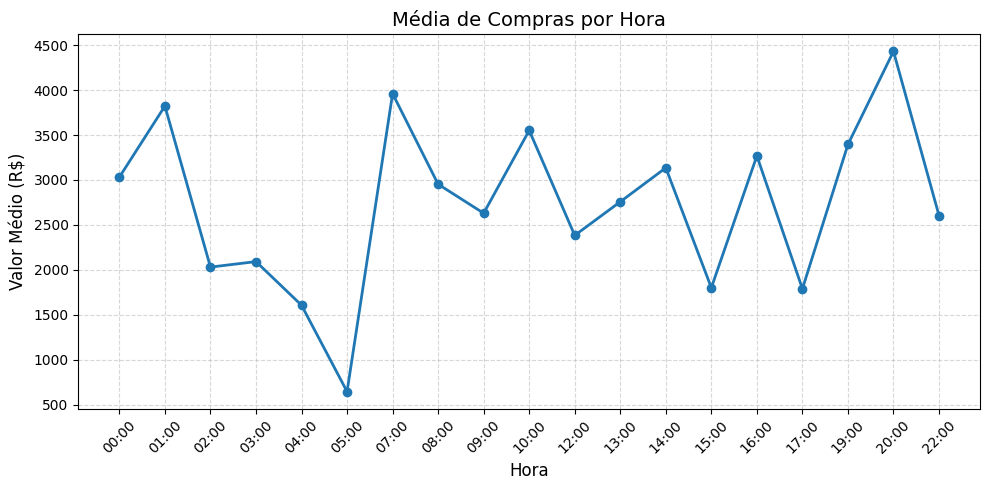

In [ ]:
#Gráfico 1

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    media_por_hora["hora"],
    media_por_hora["Valor Médio de Compra"],
    marker="o",
    linewidth=2
)

plt.title("Média de Compras por Hora", fontsize=14)
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Valor Médio (R$)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

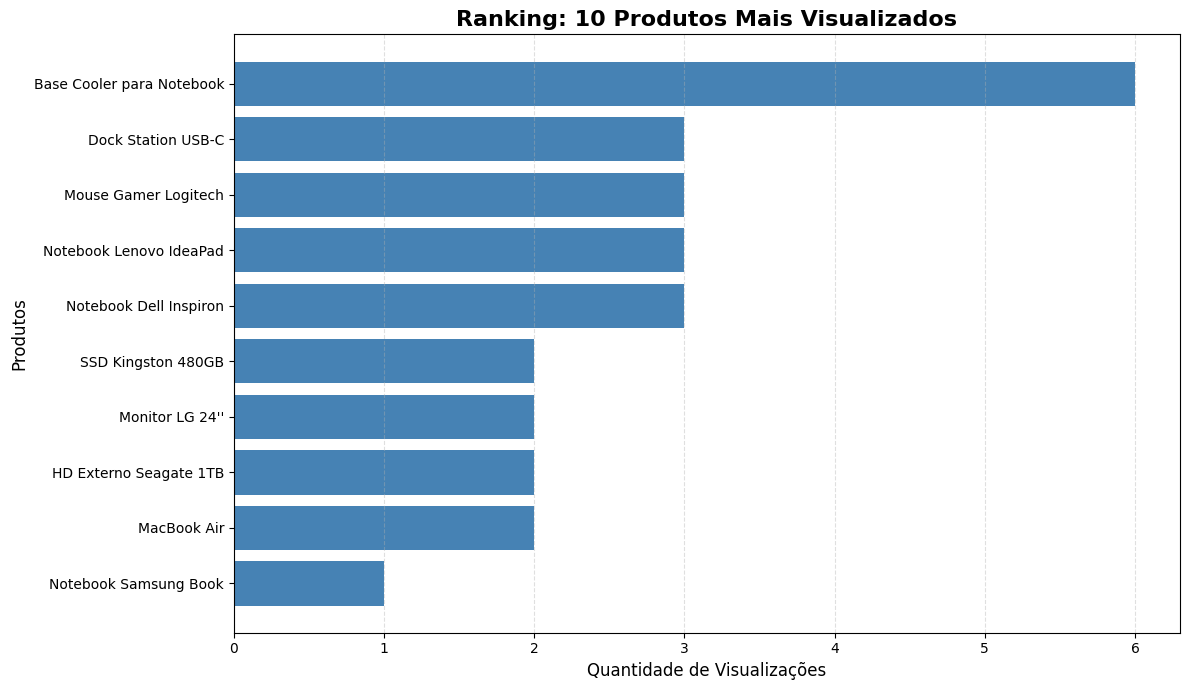

In [ ]:
#Gráfico 2
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.barh(top_produtos["Produto"][::-1],
         top_produtos["Quantidade de Visualizações"][::-1],
         color="steelblue")

plt.title("Ranking: 10 Produtos Mais Visualizados", fontsize=16, fontweight='bold')
plt.xlabel("Quantidade de Visualizações", fontsize=12)
plt.ylabel("Produtos", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()